In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\putna\Downloads\amezon _dataset reviews\amezon_reviews.xls")

## Eda

In [3]:
df.head()

,label,review
0,1,Stuning even for the non-gamer: This sound tra...
1,1,The best soundtrack ever to anything.: I'm rea...
2,1,Amazing!: This soundtrack is my favorite music...
3,1,Excellent Soundtrack: I truly like this soundt...
4,1,"Remember, Pull Your Jaw Off The Floor After He..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   label   250000 non-null  int64 
 1   review  250000 non-null  object
dtypes: int64(1), object(1)
memory usage: 3.8+ MB


In [5]:
df.shape

(250000, 2)

In [6]:
df.isna().sum()

label     0
review    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['label'].value_counts()

label
1    127208
0    122792
Name: count, dtype: int64

In [9]:
df['review'].str.len()

0         426
1         509
2         760
3         743
4         481
         ... 
249995    325
249996    518
249997    375
249998    279
249999    855
Name: review, Length: 250000, dtype: int64

In [10]:
df['review'].describe()

count                                                250000
unique                                               250000
top       Stuning even for the non-gamer: This sound tra...
freq                                                      1
Name: review, dtype: object

In [11]:
df["review"].str.len().describe()

count    250000.000000
mean        441.054404
std         240.211920
min         100.000000
25%         237.000000
50%         395.000000
75%         610.000000
max        1015.000000
Name: review, dtype: float64

## Text preprocesing

In [12]:
import re
import nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Run only once
nltk.download('stopwords')
nltk.download('wordnet')

# ==================== Initialize Stopwords and Negations ====================
# 1. Load normal stopwords from NLTK
stop_words = set(stopwords.words('english'))

# 2. List of words that give a negative meaning (Negation words)
negation_words = {'not', 'no', 'never', 'neither', 'nor', 'cannot', "isn't", "aren't", "wasn't", "weren't", "haven't", "hasn't", "hadn't", "won't", "wouldn't", "don't", "doesn't", "didn't", "can't", "couldn't", "shouldn't"}

# 3. Remove negation words from the main stopwords list (Subtracting them)
stop_words = stop_words - negation_words
# ============================================================================

lemmatizer = WordNetLemmatizer()

# Text Preprocessing Function
def clean_text(text):

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # 3. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 4. Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 5. Tokenization
    words = text.split()

    # 6. Remove stopwords (Modified stop_words list will be applied here)
    words = [word for word in words if word not in stop_words]

    # 7. Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    # 8. Join words
    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\putna\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\putna\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Convert raw text to clean text

In [13]:
sample_review = df.loc[0, "review"]
df["review"] = df["review"].apply(clean_text)
df["review"].head()


In [17]:
# Features (Input)
X = df["review"]

# Target (Output)
y = df["label"]

In [18]:
X

0         stuning even nongamer sound track beautiful pa...
1         best soundtrack ever anything im reading lot r...
2         amazing soundtrack favorite music time hand in...
3         excellent soundtrack truly like soundtrack enj...
4         remember pull jaw floor hearing youve played g...
                                ...                        
249995    not best series liked series one subject matte...
249996    kate shugakbest character ive read since ross ...
249997    fine story enjoyed play fire start finish disc...
249998    agendadriven unfortunate m stabenow written po...
249999    preachy preachy preachy kate shugak getting ar...
Name: review, Length: 250000, dtype: object

In [19]:
y

0         1
1         1
2         1
3         1
4         1
         ..
249995    0
249996    1
249997    1
249998    0
249999    0
Name: label, Length: 250000, dtype: int64

## Train test split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
print("Training Reviews :", len(X_train))
print("Testing Reviews  :", len(X_test))

print("\nTraining Labels :", len(y_train))
print("Testing Labels  :", len(y_test))

Training Reviews : 200000
Testing Reviews  : 50000

Training Labels : 200000
Testing Labels  : 50000


## Tokenization

In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(oov_token="<OOV>")

tokenizer.fit_on_texts(X_train)

In [23]:
vocab_size = len(tokenizer.word_index) + 1

    num_words=50000,
print("Vocabulary Size:", vocab_size)

Vocabulary Size: 269154


In [24]:

tokenizer = Tokenizer(
    num_words=50000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

## convert to sequence

In [25]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

## Finding token lenght of every review

In [26]:
review_lengths = [len(review) for review in X_train_seq]

In [27]:
import pandas as pd

pd.Series(review_lengths).describe()

count    200000.000000
mean         41.812100
std          22.475245
min           0.000000
25%          23.000000
50%          38.000000
75%          57.000000
max         210.000000
dtype: float64

In [28]:
import numpy as np

print("90th Percentile :", np.percentile(review_lengths, 90))
print("95th Percentile :", np.percentile(review_lengths, 95))
print("99th Percentile :", np.percentile(review_lengths, 99))

90th Percentile : 76.0
95th Percentile : 85.0
99th Percentile : 95.0


## Padding

In [29]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen = 100

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=maxlen,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=maxlen,
    padding="post",
    truncating="post"
)

In [30]:
print(X_train_pad.shape)
print(X_test_pad.shape)

(200000, 100)
(50000, 100)


In [31]:
#!pip install gensim

In [32]:
from gensim.models import Word2Vec

In [33]:
sentences = [review.split() for review in X_train]

## Train word2vec

In [34]:
word2vec_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


### checking

In [40]:
print(word2vec_model.wv.most_similar("no"))

[('whatsoever', 0.5838686227798462), ('none', 0.5601804852485657), ('nothing', 0.49391865730285645), ('without', 0.48436594009399414), ('feller', 0.4671887457370758), ('solved', 0.4636777639389038), ('unorginal', 0.45575451850891113), ('there', 0.4487640857696533), ('lack', 0.44391435384750366), ('nonexistent', 0.4428805410861969)]


In [41]:
print("Vocabulary Size:", len(word2vec_model.wv.index_to_key))

print(word2vec_model.wv.most_similar("good"))
print(word2vec_model.wv.most_similar("bad"))
print(word2vec_model.wv.most_similar("movie"))
print(word2vec_model.wv.most_similar("love"))

Vocabulary Size: 88351
[('great', 0.7754085063934326), ('decent', 0.7477144598960876), ('bad', 0.7183701395988464), ('ok', 0.6146504282951355), ('nice', 0.6082941889762878), ('okay', 0.5870773196220398), ('excellent', 0.5862934589385986), ('cool', 0.5434888601303101), ('neat', 0.5228801965713501), ('awesome', 0.5213760137557983)]
[('good', 0.7183701395988464), ('terrible', 0.6839730739593506), ('horrible', 0.6819810271263123), ('awful', 0.6634441018104553), ('stink', 0.5968358516693115), ('dumb', 0.5908562541007996), ('poor', 0.5907971262931824), ('lame', 0.5875288844108582), ('stupid', 0.586435854434967), ('suck', 0.5818472504615784)]
[('film', 0.8780300617218018), ('flick', 0.7810420989990234), ('comedy', 0.708145260810852), ('moviei', 0.6840711832046509), ('theater', 0.6471689343452454), ('horror', 0.6464021801948547), ('gladiator', 0.6248494982719421), ('scary', 0.6244402527809143), ('moviethe', 0.6184461116790771), ('tcm', 0.6087222695350647)]
[('loved', 0.6964048147201538), ('gro

## Creating Embedding Matrix

In [42]:
import numpy as np

embedding_dim = 100
embedding_matrix = np.zeros((50000, embedding_dim))

for word, index in tokenizer.word_index.items():
    if index < 50000:
        if word in word2vec_model.wv:
            embedding_matrix[index] = word2vec_model.wv[word]

In [43]:
print(embedding_matrix.shape)

(50000, 100)


In [44]:
print(y_train[:20])
print(y_test[:20])

print(np.unique(y_train, return_counts=True))

31420     0
27078     1
174267    1
185202    0
104833    0
21034     1
204470    0
159298    0
19596     1
39183     0
218122    1
149439    0
29932     0
26233     1
217852    1
132151    1
28059     1
82623     0
215187    1
189375    0
Name: label, dtype: int64
195332    1
21160     1
247199    1
147633    1
137894    1
60926     1
205498    0
132160    1
101748    1
40090     1
26459     1
208702    0
245841    1
125841    0
220394    1
29873     1
1767      0
97587     1
58161     1
64892     1
Name: label, dtype: int64
(array([0, 1]), array([ 98234, 101766]))


NameError: name 'model' is not defined

## building simple architecture 

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense

model = Sequential([
    Embedding(input_dim=50000,
              output_dim=100,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=False),

    Bidirectional(GRU(64)),

    Dense(1, activation='sigmoid')
])

C:\Users\putna\anaconda3\anconda files\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [43]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [44]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │       5,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,000,000 (19.07 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,000,000 (19.07 MB)

In [45]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=5,
    batch_size=128
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 249s 156ms/step - accuracy: 0.8790 - loss: 0.2849 - val_accuracy: 0.8937 - val_loss: 0.2548
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 364s 233ms/step - accuracy: 0.9015 - loss: 0.2386 - val_accuracy: 0.9033 - val_loss: 0.2347
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 391s 238ms/step - accuracy: 0.9096 - loss: 0.2221 - val_accuracy: 0.9015 - val_loss: 0.2373
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 374s 239ms/step - accuracy: 0.9153 - loss: 0.2097 - val_accuracy: 0.9041 - val_loss: 0.2340
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 364s 233ms/step - accuracy: 0.9198 - loss: 0.1989 - val_accuracy: 0.9076 - val_loss: 0.2283


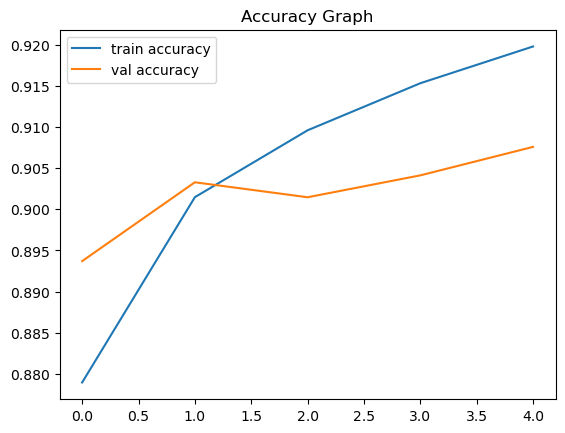

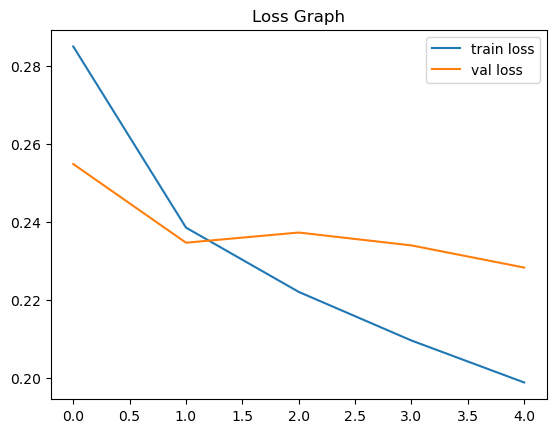

In [46]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

## overfit 

In [47]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

if train_acc > val_acc + 0.05:
    print("⚠️ Overfitting detected (train high, val low)")
elif train_acc < 0.7 and val_acc < 0.7:
    print("⚠️ Underfitting detected (both low accuracy)")
else:
    print("✅ Model is good / balanced")

✅ Model is good / balanced


## Hyperparameter Tuning 

In [50]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [49]:
model = Sequential([
    Embedding(input_dim=50000,
              output_dim=100,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=False),

    Bidirectional(GRU(64, return_sequences=False)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

In [51]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [52]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [53]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 361s 226ms/step - accuracy: 0.8605 - loss: 0.3271 - val_accuracy: 0.8887 - val_loss: 0.2675
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 341s 218ms/step - accuracy: 0.8915 - loss: 0.2652 - val_accuracy: 0.8941 - val_loss: 0.2538
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 357s 228ms/step - accuracy: 0.8984 - loss: 0.2504 - val_accuracy: 0.9003 - val_loss: 0.2442
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 356s 228ms/step - accuracy: 0.9031 - loss: 0.2405 - val_accuracy: 0.9017 - val_loss: 0.2402
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 361s 231ms/step - accuracy: 0.9069 - loss: 0.2317 - val_accuracy: 0.9051 - val_loss: 0.2357
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 392s 225ms/step - accuracy: 0.9101 - loss: 0.2238 - val_accuracy: 0.9062 - val_loss: 0.2308
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1946s 1s/step - accuracy: 0.9130 - loss: 0.2176 - val_accuracy: 0.9070 - val_loss: 0.2288
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 332s 212ms/step - accu

## Prediction probability

In [54]:
import numpy as np

# predict probabilities
y_pred_prob = model.predict(X_test_pad)

print(y_pred_prob[:10])

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step
[[0.70055825]
 [0.9990215 ]
 [0.39369714]
 [0.79543734]
 [0.35680026]
 [0.6876914 ]
 [0.00706228]
 [0.9977638 ]
 [0.69162345]
 [0.9990872 ]]


## Convert probability class

In [57]:
y_pred = (y_pred_prob > 0.5).astype("int32")

## accuracy calculation

In [58]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

Test Accuracy: 0.90698


## hyp

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Embedding(input_dim=50000,
              output_dim=100,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=False),

    Bidirectional(GRU(128, return_sequences=False)),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

In [61]:
model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [62]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [63]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 426s 135ms/step - accuracy: 0.8666 - loss: 0.3128 - val_accuracy: 0.8904 - val_loss: 0.2604
Epoch 2/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 474s 145ms/step - accuracy: 0.8928 - loss: 0.2596 - val_accuracy: 0.8955 - val_loss: 0.2529
Epoch 3/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 459s 147ms/step - accuracy: 0.9017 - loss: 0.2417 - val_accuracy: 0.9034 - val_loss: 0.2385
Epoch 4/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 448s 143ms/step - accuracy: 0.9080 - loss: 0.2282 - val_accuracy: 0.9057 - val_loss: 0.2316
Epoch 5/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 517s 148ms/step - accuracy: 0.9129 - loss: 0.2174 - val_accuracy: 0.9035 - val_loss: 0.2363
Epoch 6/15
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 514s 152ms/step - accuracy: 0.9180 - loss: 0.2071 - val_accuracy: 0.9073 - val_loss: 0.2319


In [65]:
import numpy as np

# predict probabilities
y_pred_prob = model.predict(X_test_pad)

print(y_pred_prob[:10])

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step
[[0.8733914 ]
 [0.9969802 ]
 [0.0951032 ]
 [0.75940704]
 [0.39449072]
 [0.5254802 ]
 [0.00114126]
 [0.99855703]
 [0.5490367 ]
 [0.9989665 ]]


In [66]:
y_pred = (y_pred_prob > 0.5).astype("int32")

In [67]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

Test Accuracy: 0.90574


## Final model Build

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ===================== MODEL-2 (FINAL SELECTED MODEL) =====================
model = Sequential([
    Embedding(
        input_dim=50000,
        output_dim=100,
        weights=[embedding_matrix],
        input_length=maxlen,
        trainable=False
    ),

    Bidirectional(GRU(64, return_sequences=False)),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

# ===================== COMPILE =====================
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ===================== EARLY STOPPING =====================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# ===================== TRAIN =====================
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop]
)

# ===================== EVALUATE =====================
loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

# ===================== SAMPLE PREDICTION =====================
pred = model.predict(X_test_pad[:10])
print(pred)

C:\Users\putna\anaconda3\anconda files\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 228s 141ms/step - accuracy: 0.8772 - loss: 0.2947 - val_accuracy: 0.9073 - val_loss: 0.2310
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 220s 141ms/step - accuracy: 0.9088 - loss: 0.2294 - val_accuracy: 0.9139 - val_loss: 0.2172
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 214s 137ms/step - accuracy: 0.9154 - loss: 0.2145 - val_accuracy: 0.9168 - val_loss: 0.2069
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 215s 138ms/step - accuracy: 0.9198 - loss: 0.2047 - val_accuracy: 0.9190 - val_loss: 0.2053
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 252s 132ms/step - accuracy: 0.9228 - loss: 0.1969 - val_accuracy: 0.9192 - val_loss: 0.2020
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 275s 140ms/step - accuracy: 0.9253 - loss: 0.1909 - val_accuracy: 0.9195 - val_loss: 0.2026
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 208s 133ms/step - accuracy: 0.9285 - loss: 0.1839 - val_accuracy: 0.9210 - val_loss: 0.2003
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 264s 169ms/step - ac

## checking overrfiting 

In [48]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

gap = train_acc - val_acc
print("Gap:", gap)

if gap > 0.05:
    print("⚠️ Overfitting detected")
else:
    print("✅ Model is good (no major overfitting)")

Train Accuracy: 0.9337049722671509
Validation Accuracy: 0.9198799729347229
Gap: 0.013824999332427979
✅ Model is good (no major overfitting)


In [49]:
from sklearn.metrics import confusion_matrix

y_pred = (model.predict(X_test_pad, verbose=0) > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))

[[22824  1734]
 [ 2218 23224]]


## testing time

In [60]:
review = "This was the worst product and expensive."

seq = tokenizer.texts_to_sequences([review])
pad = pad_sequences(seq, maxlen=maxlen)

pred = model.predict(pad, verbose=0)
print(pred[0][0])

0.2755307


In [61]:
review = "This was the worst product and more costly."

review = clean_text(review)
print("Cleaned Review:", review)

seq = tokenizer.texts_to_sequences([review])
print("Sequence:", seq)

padded = pad_sequences(seq, maxlen=maxlen)

prediction = model.predict(padded, verbose=0)[0][0]

print("Prediction:", prediction)

if prediction >= 0.6:
    print("Positive")
else:
    print("Negative")

Cleaned Review: worst product costly
Sequence: [[161, 37, 7387]]
Prediction: 0.14063011
Negative


In [55]:
reviews = [
    "Worst movie ever.",
    "I hated this movie.",
    "Absolutely terrible film.",
    "Excellent movie. I loved it."
]

for r in reviews:
    c = clean_text(r)
    s = tokenizer.texts_to_sequences([c])
    p = pad_sequences(s, maxlen=maxlen)
    pred = model.predict(p, verbose=0)[0][0]
    print(r, "->", pred)

Worst movie ever. -> 0.8573716
I hated this movie. -> 0.9594547
Absolutely terrible film. -> 0.70262265
Excellent movie. I loved it. -> 0.99812746


In [56]:
loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(acc)

0.920960009098053


## save

In [41]:
model.save("sentiment_model.keras")

In [42]:
import pickle

pickle.dump(tokenizer, open("tokenizer.pkl", "wb"))

In [43]:
import json

json.dump({"maxlen": maxlen}, open("config.json", "w"))

In [46]:
for word in ["worst", "movie", "ever", "seen"]:
    print(word, tokenizer.word_index.get(word))

worst 161
movie 5
ever 44
seen 150
